In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [16]:
def stat_reader(fname):
    f=open(fname)
    try:
        stat_dict = ast.literal_eval(f.readlines()[-2].strip()) #with the journalctl line
    except Exception as e:
        stat_dict="failed_rank"
    # print(stat_dict)
    return stat_dict

def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 


def filter_warmups(arrs, valid_cores=1, exp_len=11):
    # print(arrs)
    c=0
    for ind, _ in enumerate(arrs):
        arrs[ind]=[i for i in arrs[ind] if i > 0]
        if c < valid_cores:
            assert len(arrs[ind]) == exp_len
            c+=1
    return arrs






/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-5/vit_modules/1_concurrency_level/1/3_2/speed_chronosbramble-4-5-27_0.log


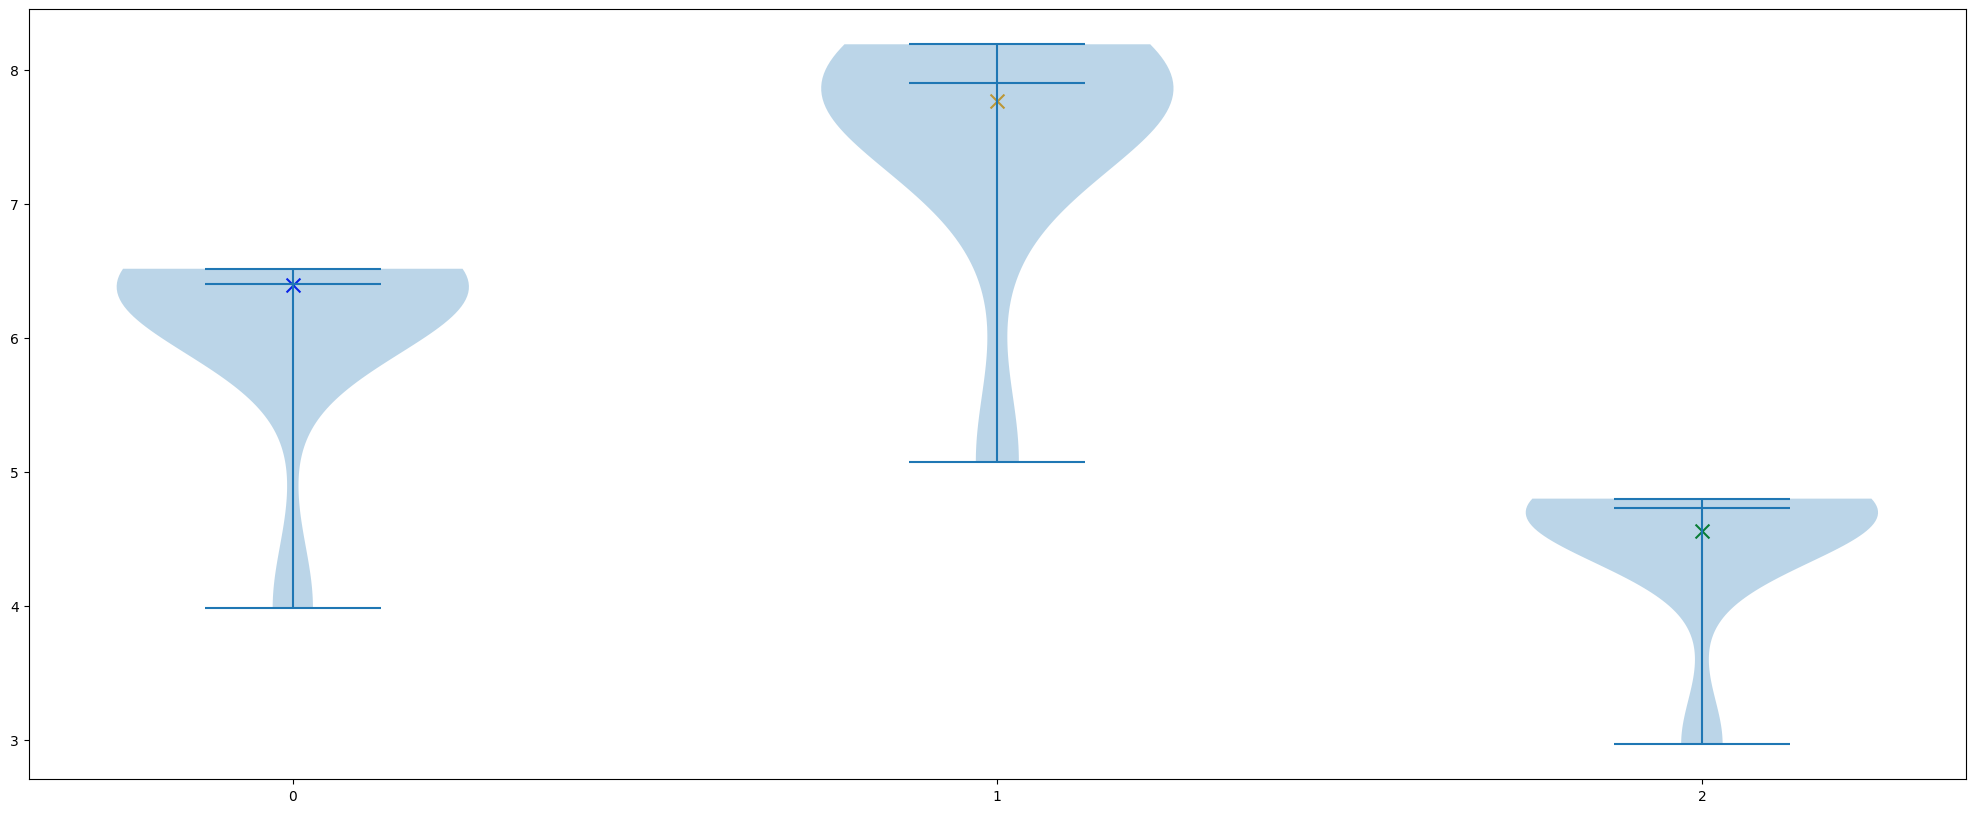

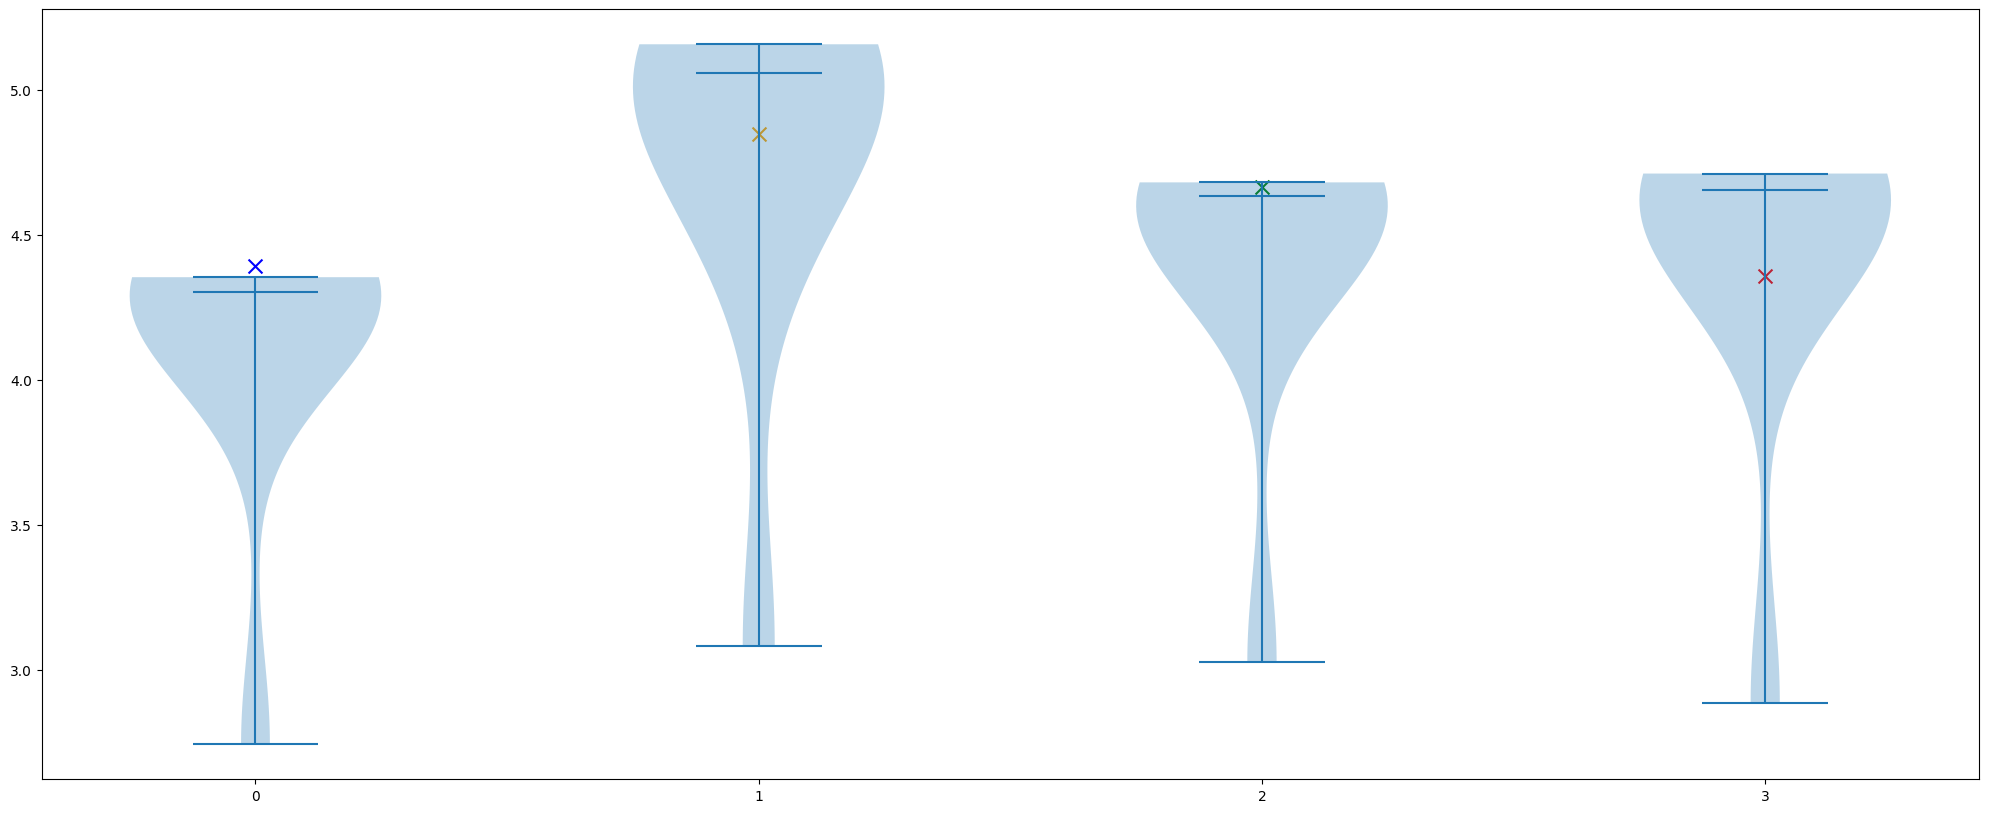

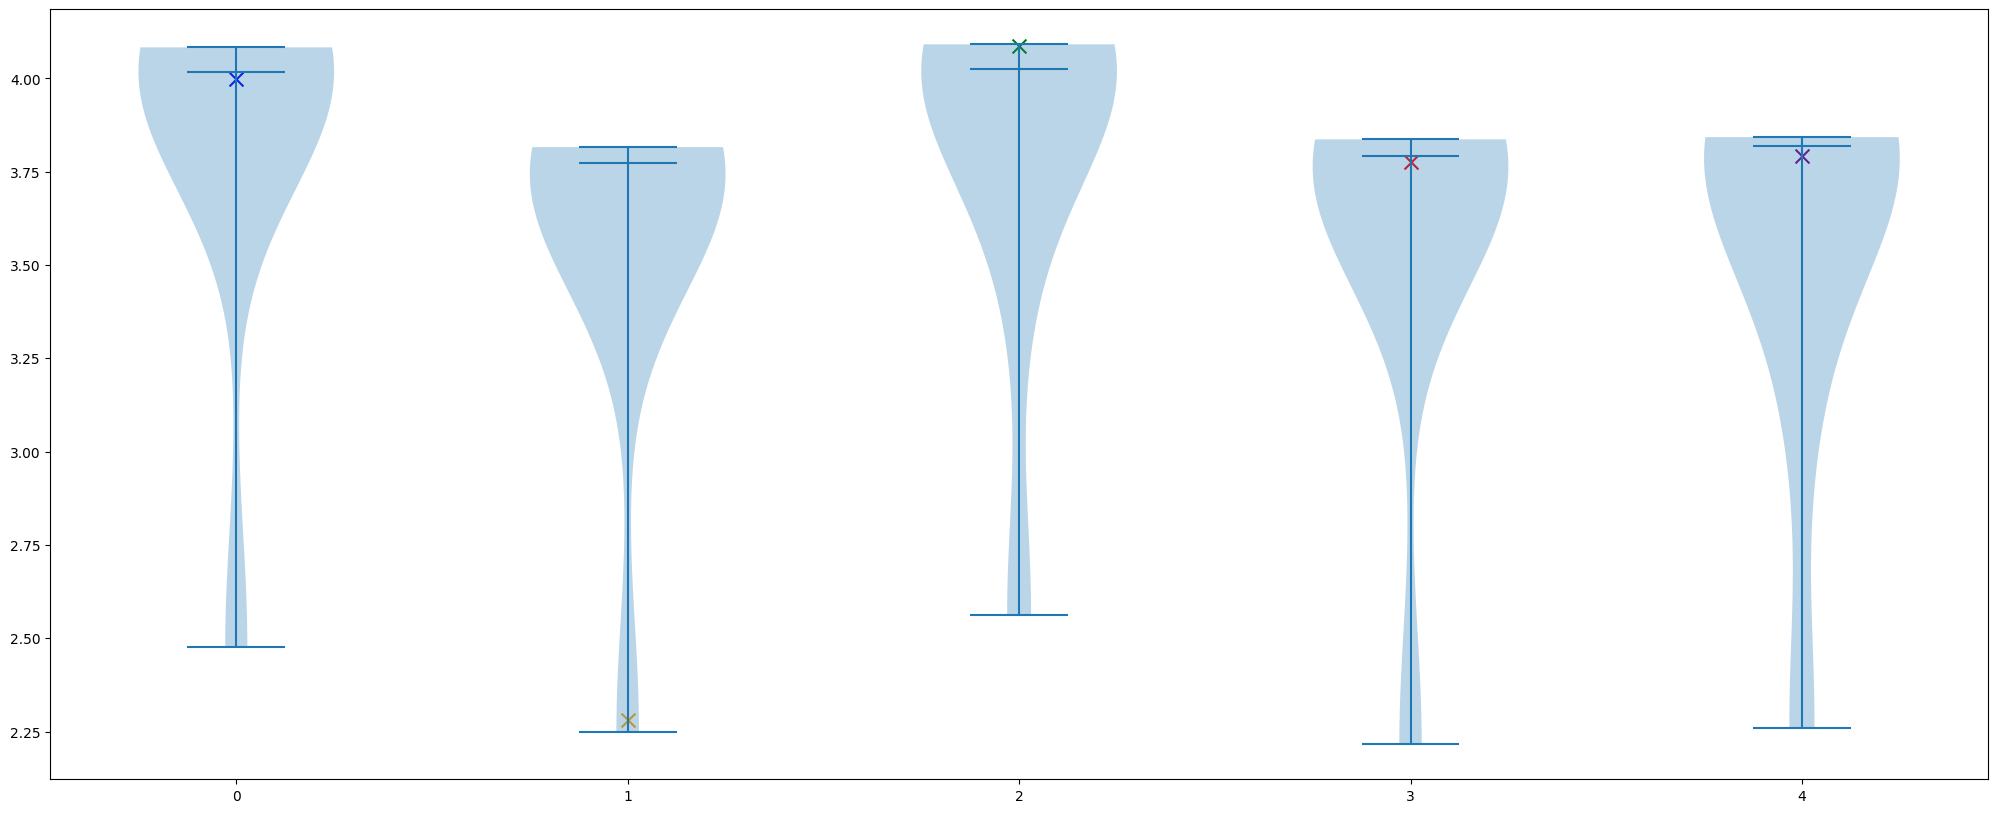

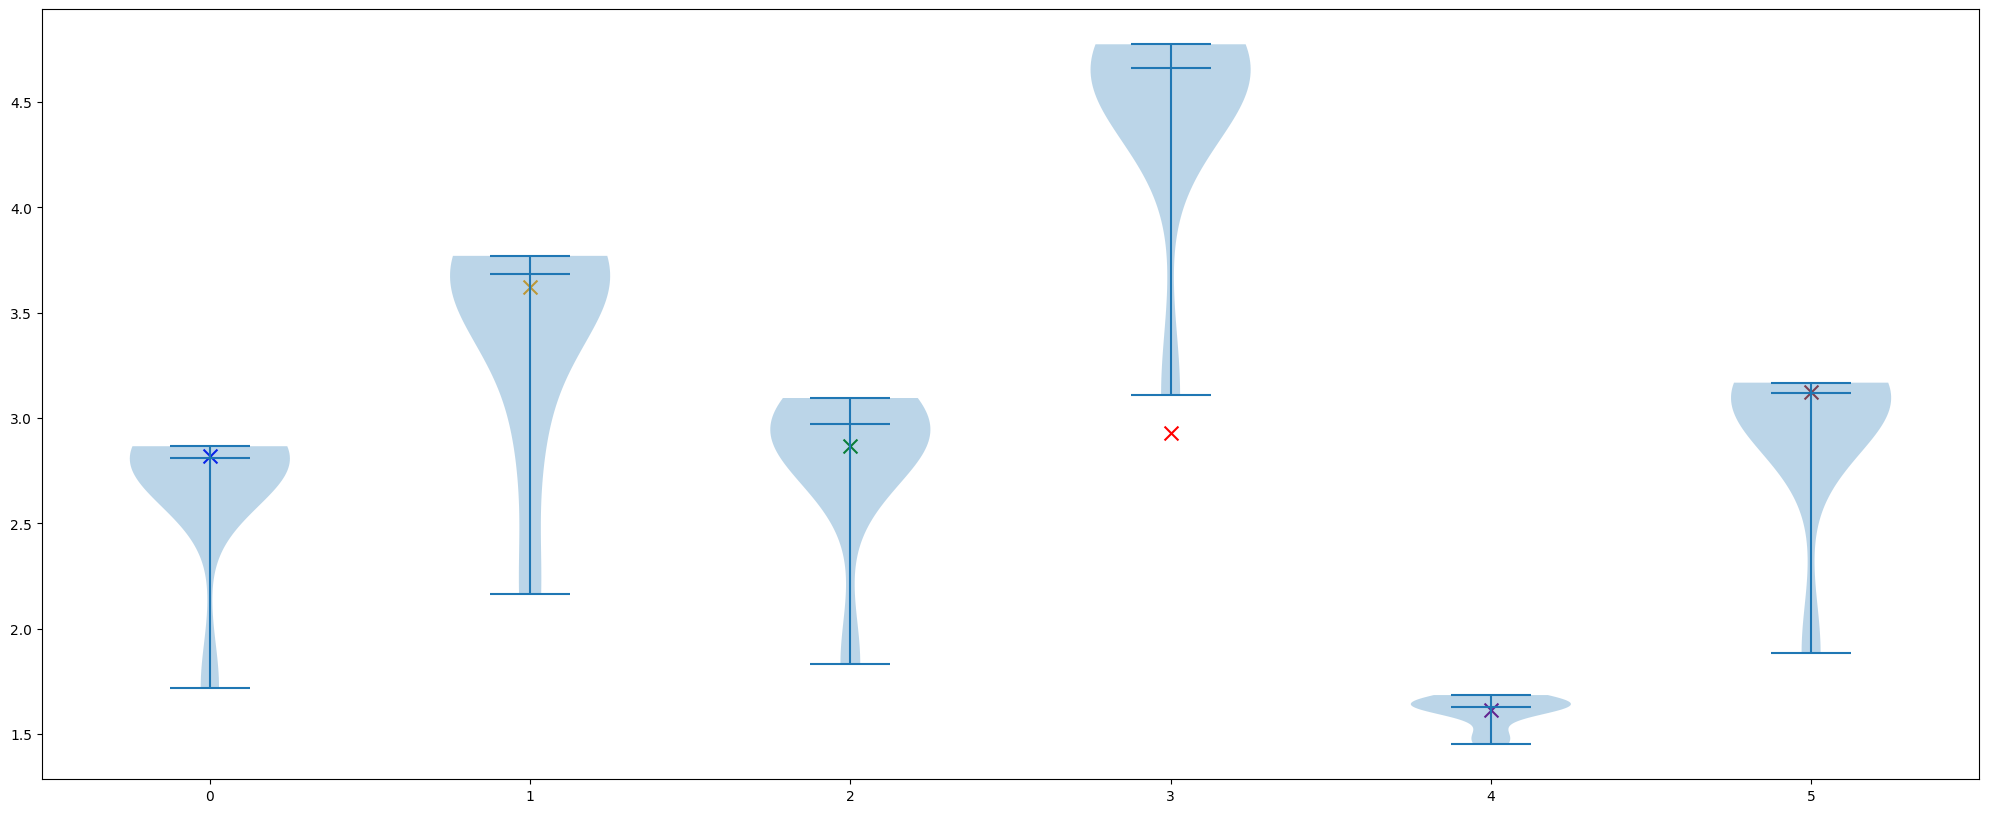

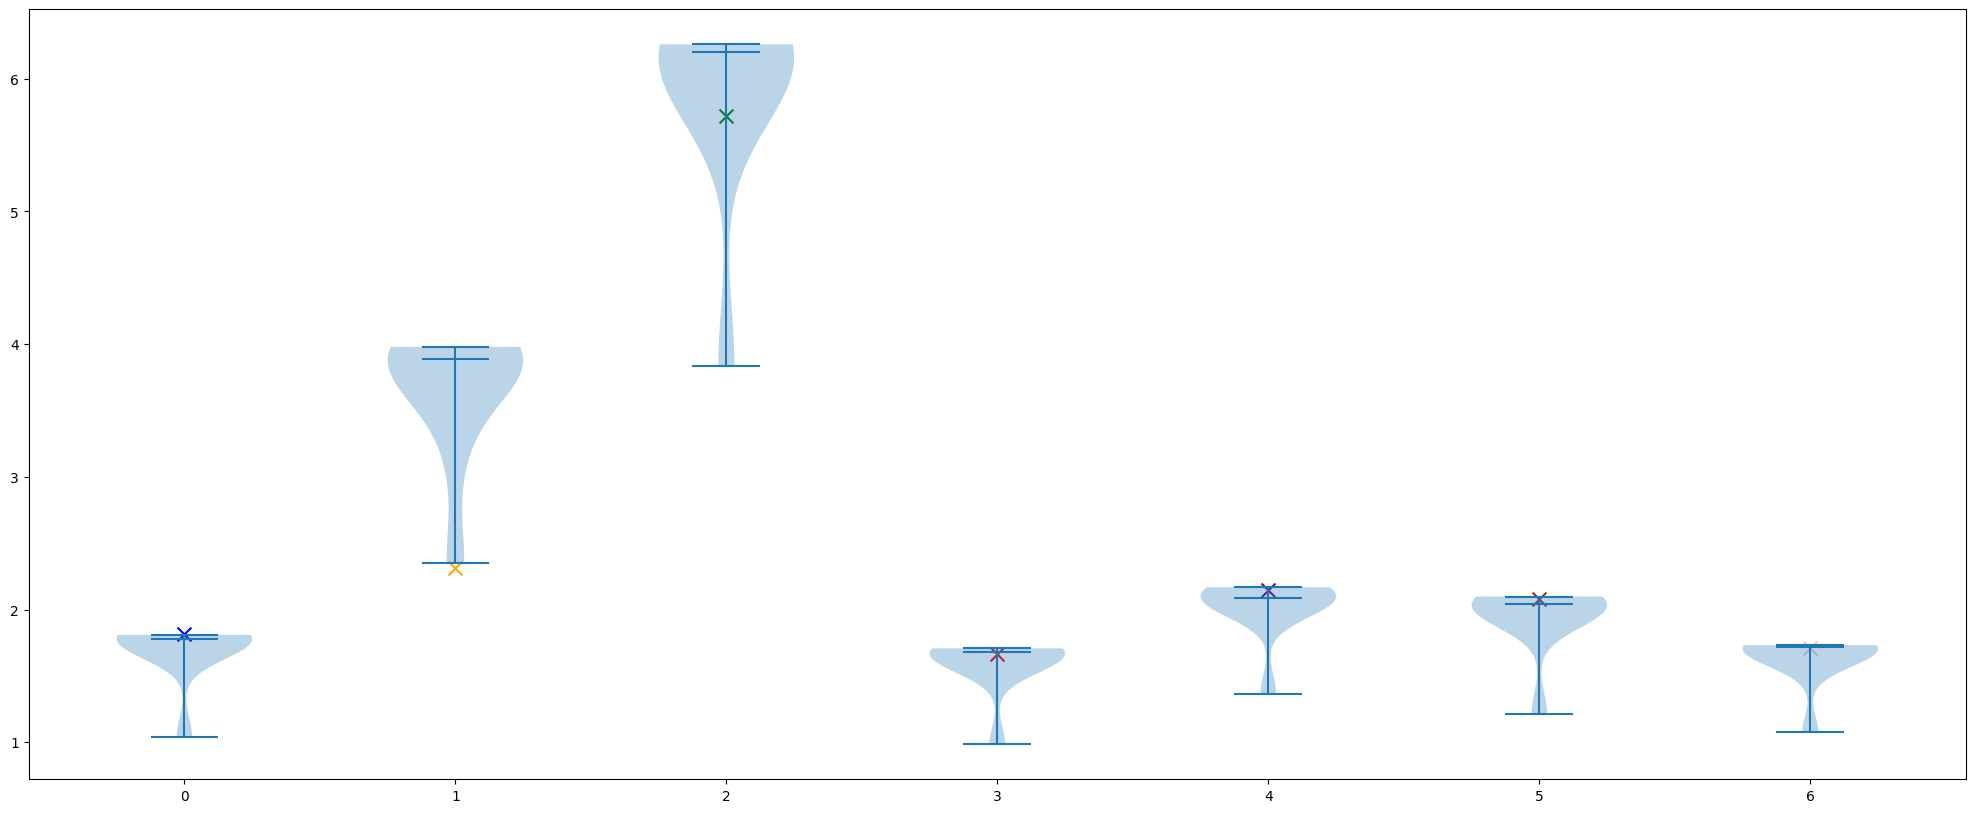

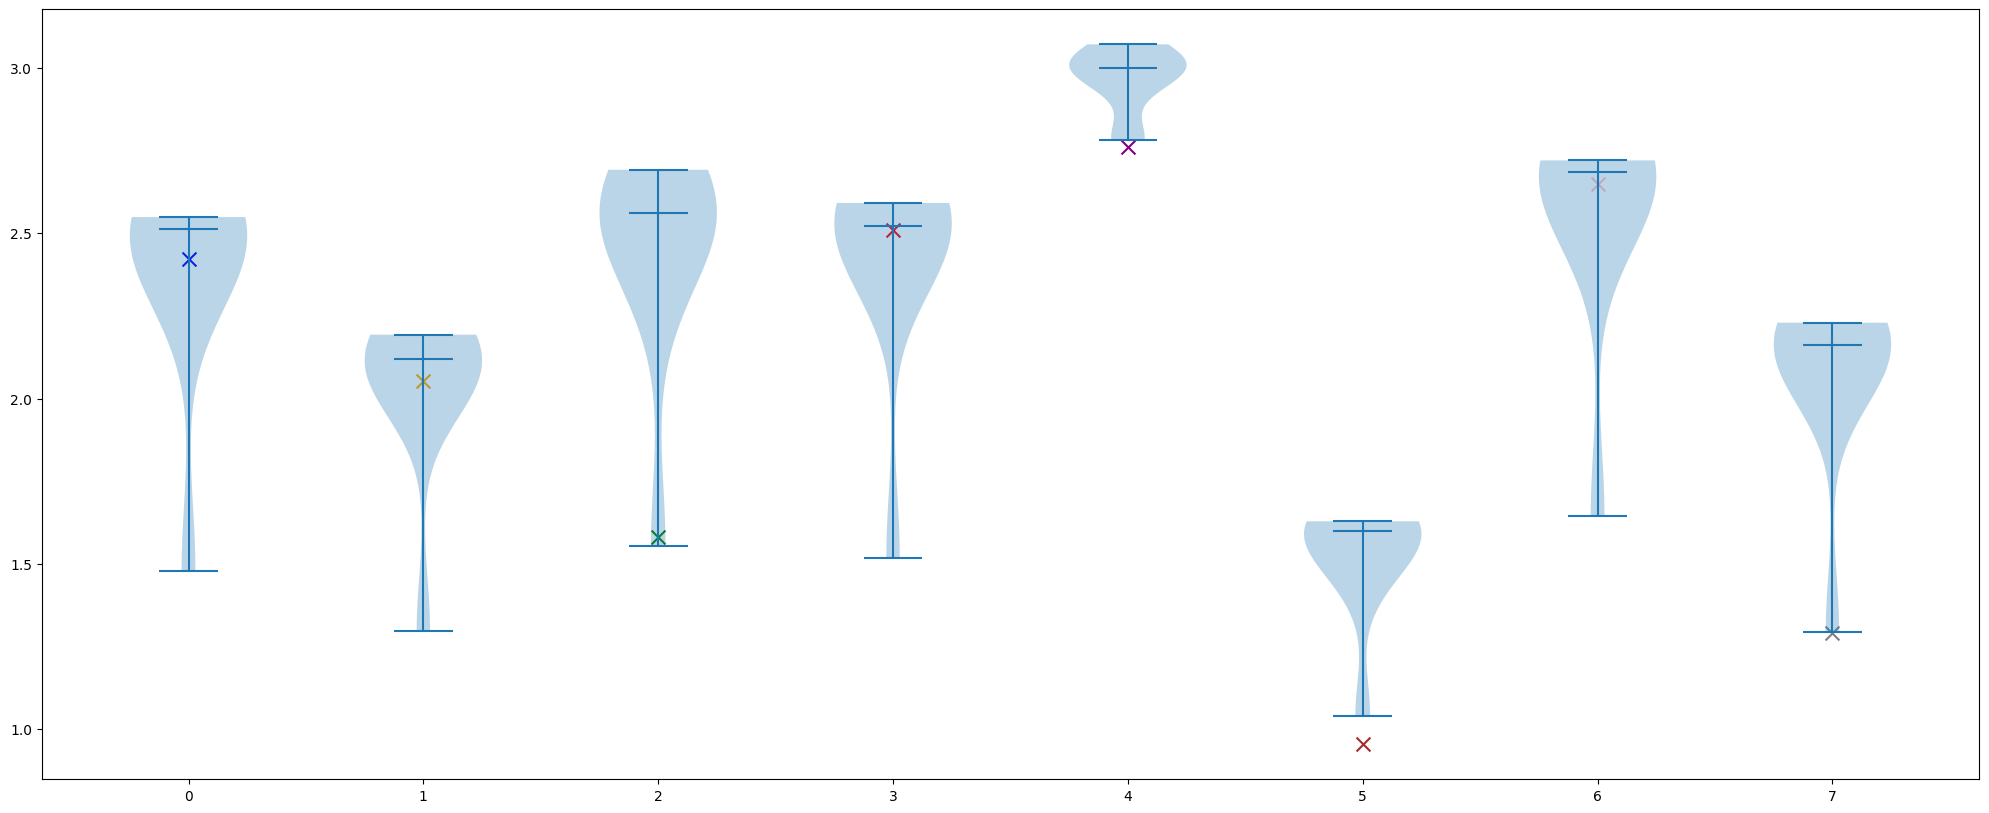

In [44]:
#1 core analysis of single_group_vit
# /Users/animeshnd/model_splitting/logs/single_group_heat/bramble-4-5/vit_modules/1_concurrency_level/1/3_1/speed_chronosbramble-4-5-9_2.log
cons = [1,10]
model="vit"
split_type="modules"
cores=[1,2,3,4]
pdu_tag="bramble-4-5"
prefix = "/Users/animeshnd/model_splitting/logs/single_group_heat/"
worlds = [3,4,5,6,7,8]
comp_times={con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons}
for con in cons:
    for world in worlds:
        for core in cores:
            for r in range(world):
                for dev in range(1,42):
                    full_path = f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_chronos{pdu_tag}-{dev}_{r}.log"
                    if Path.is_file(Path(full_path)):
                        m = stat_reader(full_path)
                        if "fail" in m:
                            print(full_path)
                            continue
                        warmups = m["warmup"][0]
                        #warmup is 4 cores, so 4 arrays, each with len == number of iters + 1 (1==warmup iter)
                        #if we used all 4 cores -> each array should be these lens -> if an array has 0s or -ve values -> bad array!
                        warmups= filter_warmups(warmups, valid_cores=core, exp_len=11)
                        comp_times[con][world][r].append(m["comp_times"][0]/10)

colors=["blue", "orange", "green", "red", "purple", "brown", "pink", "grey"]
axs_map={}
for k in comp_times[1]:
    fig, axs = plt.subplots(figsize=(25,10))
    axs_map[k]=axs
    for r in comp_times[1][k]:
        axs.scatter(r, comp_times[1][k][r], marker="x", s=100, color=colors[r])
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

for k in comp_times[10]:
    axs=axs_map[k]
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    axs.violinplot([v for v in comp_times[10][k].values()], positions=np.arange(0,k, 1), showmedians=True)
    axs.set_xticks(np.arange(0,k, 1))



